In [ ]:
# create current working directory
import os

print(os.getcwd())

c:\Users\Greesha Vaishnavi\Desktop\dsprojects\Hotel_Booking_Cancellation_Prediction\research\05_model_experiments


In [ ]:
# import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    log_loss
)

In [ ]:
# transformed data paths

train_df = pd.read_csv(
    "../../artifacts/data_transformation/train_unscaled.csv"   # unscaled dat is used for tree based model
)

test_df = pd.read_csv(
    "../../artifacts/data_transformation/test_unscaled.csv"
)

In [ ]:
# seperate target and features

target_column = "is_canceled"

X_train = train_df.drop(
    columns=[target_column]
)

y_train = train_df[target_column]

X_test = test_df.drop(
    columns=[target_column]
)

y_test = test_df[target_column]

In [ ]:
# checking their shapes

print("X_train shape:", X_train.shape)  #check our transformed data
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (95512, 916)
X_test shape : (23878, 916)
y_train shape: (95512,)
y_test shape : (23878,)


# Baeline model

In [6]:
decision_tree_model = DecisionTreeClassifier(     # baseline model
    criterion="gini",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

In [ ]:
# model fit

decision_tree_model.fit(
    X_train,
    y_train
)

print("Decision Tree training completed.")

Decision Tree training completed.


In [ ]:
# Training vs testing accuracy

train_pred = decision_tree_model.predict(         
    X_train
)

test_pred = decision_tree_model.predict(
    X_test
)

train_accuracy = accuracy_score(
    y_train,
    train_pred
)

test_accuracy = accuracy_score(
    y_test,
    test_pred
)

print("Training Accuracy:", train_accuracy)   # overfitting Training is very high ,Testing is considerably lower
print("Testing Accuracy :", test_accuracy)

Training Accuracy: 0.9963355389898652
Testing Accuracy : 0.8605410838428679


In [ ]:
# Predictions and probabilities

dt_pred = decision_tree_model.predict(            
    X_test
)

dt_prob = decision_tree_model.predict_proba(
    X_test
)[:, 1]

print("Predictions completed.")

Predictions completed.


In [10]:
dt_cm = confusion_matrix(               # Confusion Matrix
    y_test,
    dt_pred
)

print("Confusion Matrix:")
print(dt_cm)

Confusion Matrix:
[[13372  1661]
 [ 1669  7176]]


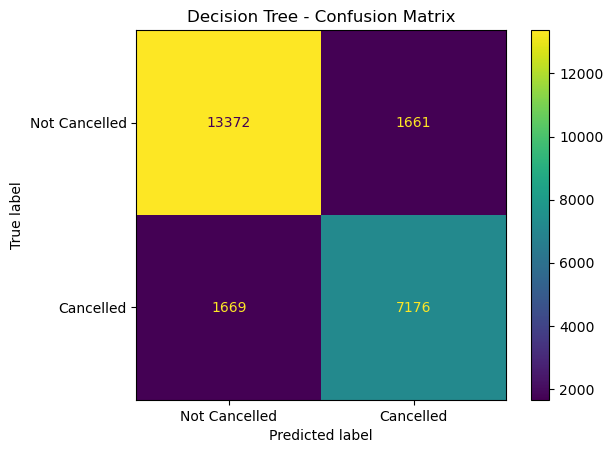

In [11]:
ConfusionMatrixDisplay(
    confusion_matrix=dt_cm,
    display_labels=["Not Cancelled", "Cancelled"]
).plot()

plt.title("Decision Tree - Confusion Matrix")
plt.show()

In [12]:
print(
    classification_report(
        y_test,
        dt_pred
    )
)

              precision    recall  f1-score   support

           0       0.89      0.89      0.89     15033
           1       0.81      0.81      0.81      8845

    accuracy                           0.86     23878
   macro avg       0.85      0.85      0.85     23878
weighted avg       0.86      0.86      0.86     23878



In [13]:
dt_accuracy = accuracy_score(              # evaluating models
    y_test,
    dt_pred
)

dt_precision = precision_score(
    y_test,
    dt_pred,
    zero_division=0
)

dt_recall = recall_score(
    y_test,
    dt_pred,
    zero_division=0
)

dt_f1 = f1_score(
    y_test,
    dt_pred,
    zero_division=0
)

tn_dt, fp_dt, fn_dt, tp_dt = dt_cm.ravel()

dt_specificity = tn_dt / (
    tn_dt + fp_dt
)

dt_roc_auc = roc_auc_score(
    y_test,
    dt_prob
)

dt_pr_auc = average_precision_score(
    y_test,
    dt_prob
)

dt_logloss = log_loss(
    y_test,
    dt_prob
)

In [14]:
print("=" * 55)
print("DECISION TREE - BASELINE EVALUATION")
print("=" * 55)

print(f"Accuracy    : {dt_accuracy:.4f}")
print(f"Precision   : {dt_precision:.4f}")
print(f"Recall      : {dt_recall:.4f}")
print(f"Specificity : {dt_specificity:.4f}")
print(f"F1 Score    : {dt_f1:.4f}")
print(f"ROC-AUC     : {dt_roc_auc:.4f}")
print(f"PR-AUC      : {dt_pr_auc:.4f}")
print(f"Log Loss    : {dt_logloss:.4f}")

DECISION TREE - BASELINE EVALUATION
Accuracy    : 0.8605
Precision   : 0.8120
Recall      : 0.8113
Specificity : 0.8895
F1 Score    : 0.8117
ROC-AUC     : 0.8523
PR-AUC      : 0.7319
Log Loss    : 4.9142


In [15]:
print(
    "Tree depth:",
    decision_tree_model.get_depth()
)

print(
    "Number of leaves:",
    decision_tree_model.get_n_leaves()
)

Tree depth: 62
Number of leaves: 9800


In [16]:
depth_values = [          # max depths to test
    3,
    5,
    7,
    10,
    15,
    20
]

In [17]:
depth_values = [3, 5, 7, 10, 15, 20]

depth_results = []

for depth in depth_values:

    model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    test_prob = model.predict_proba(X_test)[:, 1]

    # Confusion matrix
    cm = confusion_matrix(y_test, test_pred)

    tn, fp, fn, tp = cm.ravel()

    # 8 evaluation metrics
    accuracy_value = accuracy_score(
        y_test, test_pred
    )

    precision_value = precision_score(
        y_test,
        test_pred,
        zero_division=0
    )

    recall_value = recall_score(
        y_test,
        test_pred,
        zero_division=0
    )

    specificity_value = tn / (tn + fp)

    f1_value = f1_score(
        y_test,
        test_pred,
        zero_division=0
    )

    roc_auc_value = roc_auc_score(
        y_test,
        test_prob
    )

    pr_auc_value = average_precision_score(
        y_test,
        test_prob
    )

    logloss_value = log_loss(
        y_test,
        test_prob
    )

    depth_results.append({
        "max_depth": depth,

        "Train Accuracy": accuracy_score(
            y_train,
            train_pred
        ),

        "Accuracy": accuracy_value,
        "Precision": precision_value,
        "Recall": recall_value,
        "Specificity": specificity_value,
        "F1 Score": f1_value,
        "ROC-AUC": roc_auc_value,
        "PR-AUC": pr_auc_value,
        "Log Loss": logloss_value,

        "Tree Depth": model.get_depth(),
        "Leaves": model.get_n_leaves()
    })

In [18]:
depth_results_df = pd.DataFrame(
    depth_results
)

depth_results_df

,max_depth,Train Accuracy,Accuracy,Precision,Recall,Specificity,F1 Score,ROC-AUC,PR-AUC,Log Loss,Tree Depth,Leaves
0,3,0.757957,0.755298,0.702237,0.589259,0.852990,0.640807,0.777300,0.683680,0.488836,3,8
1,5,0.797020,0.798224,0.704978,0.782928,0.807224,0.741911,0.874058,0.798467,0.400946,5,22
2,7,0.825844,0.825823,0.766674,0.761560,0.863633,0.764109,0.905462,0.848274,0.368997,7,52
3,10,0.852877,0.846763,0.828228,0.739740,0.909732,0.781487,0.925148,0.880259,0.356055,10,187
4,15,0.885931,0.862551,0.829133,0.792199,0.903945,0.810245,0.929300,0.883298,0.666557,15,1222
5,20,0.926114,0.867954,0.816152,0.830639,0.889909,0.823332,0.909814,0.835936,1.730826,20,3605


At dept 20 the values are good to decide we consider depth as 20 and next step is min_sample split

In [19]:
split_values = [2, 5, 10, 20, 50, 100]      # min_samples_split

In [20]:
split_results = []

for min_split in split_values:

    model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=20,
        min_samples_split=min_split,
        min_samples_leaf=1,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    test_prob = model.predict_proba(X_test)[:, 1]

    # Confusion Matrix
    cm = confusion_matrix(y_test, test_pred)

    tn, fp, fn, tp = cm.ravel()

    # 8 Evaluation Metrics
    accuracy_value = accuracy_score(
        y_test,
        test_pred
    )

    precision_value = precision_score(
        y_test,
        test_pred,
        zero_division=0
    )

    recall_value = recall_score(
        y_test,
        test_pred,
        zero_division=0
    )

    specificity_value = tn / (tn + fp)

    f1_value = f1_score(
        y_test,
        test_pred,
        zero_division=0
    )

    roc_auc_value = roc_auc_score(
        y_test,
        test_prob
    )

    pr_auc_value = average_precision_score(
        y_test,
        test_prob
    )

    logloss_value = log_loss(
        y_test,
        test_prob
    )

    split_results.append({
        "min_samples_split": min_split,

        "Train Accuracy": accuracy_score(
            y_train,
            train_pred
        ),

        "Accuracy": accuracy_value,
        "Precision": precision_value,
        "Recall": recall_value,
        "Specificity": specificity_value,
        "F1 Score": f1_value,
        "ROC-AUC": roc_auc_value,
        "PR-AUC": pr_auc_value,
        "Log Loss": logloss_value,

        "Tree Depth": model.get_depth(),
        "Leaves": model.get_n_leaves()
    })

In [21]:
split_results_df = pd.DataFrame(
    split_results
)

split_results_df

,min_samples_split,Train Accuracy,Accuracy,Precision,Recall,Specificity,F1 Score,ROC-AUC,PR-AUC,Log Loss,Tree Depth,Leaves
0,2,0.926114,0.867954,0.816152,0.830639,0.889909,0.823332,0.909814,0.835936,1.730826,20,3605
1,5,0.922439,0.869420,0.818485,0.831995,0.891439,0.825185,0.915124,0.846779,1.540928,20,3241
2,10,0.916398,0.866907,0.817053,0.825551,0.891239,0.821280,0.919373,0.859507,1.298128,20,2796
3,20,0.907823,0.867284,0.818805,0.824081,0.892703,0.821435,0.928037,0.881246,0.925166,20,2213
4,50,0.894244,0.868414,0.825328,0.817863,0.898157,0.821579,0.937580,0.899617,0.552330,20,1517
5,100,0.883816,0.866279,0.828376,0.805992,0.901749,0.817031,0.938958,0.906178,0.435328,20,1080


In [22]:
leaf_values = [1, 2, 5, 10, 20, 50]     # min_samples_leaf

In [23]:
leaf_results = []

for min_leaf in leaf_values:

    model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=20,
        min_samples_split=2,
        min_samples_leaf=min_leaf,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    test_prob = model.predict_proba(X_test)[:, 1]

    # Confusion Matrix
    cm = confusion_matrix(y_test, test_pred)

    tn, fp, fn, tp = cm.ravel()

    # 8 Evaluation Metrics
    accuracy_value = accuracy_score(
        y_test,
        test_pred
    )

    precision_value = precision_score(
        y_test,
        test_pred,
        zero_division=0
    )

    recall_value = recall_score(
        y_test,
        test_pred,
        zero_division=0
    )

    specificity_value = tn / (tn + fp)

    f1_value = f1_score(
        y_test,
        test_pred,
        zero_division=0
    )

    roc_auc_value = roc_auc_score(
        y_test,
        test_prob
    )

    pr_auc_value = average_precision_score(
        y_test,
        test_prob
    )

    logloss_value = log_loss(
        y_test,
        test_prob
    )

    leaf_results.append({
        "min_samples_leaf": min_leaf,

        "Train Accuracy": accuracy_score(
            y_train,
            train_pred
        ),

        "Accuracy": accuracy_value,
        "Precision": precision_value,
        "Recall": recall_value,
        "Specificity": specificity_value,
        "F1 Score": f1_value,
        "ROC-AUC": roc_auc_value,
        "PR-AUC": pr_auc_value,
        "Log Loss": logloss_value,

        "Tree Depth": model.get_depth(),
        "Leaves": model.get_n_leaves()
    })

In [24]:
leaf_results_df = pd.DataFrame(
    leaf_results
)

leaf_results_df

,min_samples_leaf,Train Accuracy,Accuracy,Precision,Recall,Specificity,F1 Score,ROC-AUC,PR-AUC,Log Loss,Tree Depth,Leaves
0,1,0.926114,0.867954,0.816152,0.830639,0.889909,0.823332,0.909814,0.835936,1.730826,20,3605
1,2,0.919277,0.867284,0.817948,0.825438,0.891904,0.821676,0.912638,0.843087,1.634071,20,3484
2,5,0.907122,0.864855,0.818048,0.816846,0.893102,0.817446,0.924366,0.875527,1.098630,20,2875
3,10,0.896202,0.866153,0.824320,0.811645,0.898224,0.817933,0.933494,0.896437,0.721294,20,2157
4,20,0.884402,0.865818,0.825355,0.808932,0.899288,0.817061,0.937193,0.905681,0.525005,20,1542
5,50,0.871545,0.858615,0.831254,0.775806,0.907337,0.802573,0.936293,0.906398,0.382877,20,865


In [25]:
criterion_values = ["gini", "entropy"]

In [26]:
criterion_results = []

for criterion_value in criterion_values:

    model = DecisionTreeClassifier(
        criterion=criterion_value,
        max_depth=20,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    test_prob = model.predict_proba(X_test)[:, 1]

    # Confusion Matrix
    cm = confusion_matrix(y_test, test_pred)

    tn, fp, fn, tp = cm.ravel()

    # 8 Evaluation Metrics
    accuracy_value = accuracy_score(
        y_test,
        test_pred
    )

    precision_value = precision_score(
        y_test,
        test_pred,
        zero_division=0
    )

    recall_value = recall_score(
        y_test,
        test_pred,
        zero_division=0
    )

    specificity_value = tn / (tn + fp)

    f1_value = f1_score(
        y_test,
        test_pred,
        zero_division=0
    )

    roc_auc_value = roc_auc_score(
        y_test,
        test_prob
    )

    pr_auc_value = average_precision_score(
        y_test,
        test_prob
    )

    logloss_value = log_loss(
        y_test,
        test_prob
    )

    criterion_results.append({
        "Criterion": criterion_value,

        "Train Accuracy": accuracy_score(
            y_train,
            train_pred
        ),

        "Accuracy": accuracy_value,
        "Precision": precision_value,
        "Recall": recall_value,
        "Specificity": specificity_value,
        "F1 Score": f1_value,
        "ROC-AUC": roc_auc_value,
        "PR-AUC": pr_auc_value,
        "Log Loss": logloss_value,

        "Tree Depth": model.get_depth(),
        "Leaves": model.get_n_leaves()
    })

In [27]:
criterion_results_df = pd.DataFrame(
    criterion_results
)

criterion_results_df

,Criterion,Train Accuracy,Accuracy,Precision,Recall,Specificity,F1 Score,ROC-AUC,PR-AUC,Log Loss,Tree Depth,Leaves
0,gini,0.926114,0.867954,0.816152,0.830639,0.889909,0.823332,0.909814,0.835936,1.730826,20,3605
1,entropy,0.913561,0.865944,0.820609,0.816620,0.894964,0.818609,0.919297,0.852400,1.522659,20,2975


# Hyperparameter tuning

In [28]:
from sklearn.model_selection import GridSearchCV

In [29]:
dt_param_grid = {
    "criterion": ["gini", "entropy"],   # Parameter grid
    "max_depth": [15, 20],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10]
}

dt_param_grid

{'criterion': ['gini', 'entropy'],
 'max_depth': [15, 20],
 'min_samples_split': [2, 10, 20],
 'min_samples_leaf': [1, 5, 10]}

2 criteria
× 2 depths
× 3 split values
× 3 leaf values
= 36 combinations  

36* 5 folds cross validation = 180 fits

In [30]:
dt_grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=42
    ),
    param_grid=dt_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

In [31]:
dt_grid_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [15, 20], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [2, 10, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [32]:
print("Best Parameters:")
print(dt_grid_search.best_params_)

print(
    "Best CV F1 Score:",
    dt_grid_search.best_score_
)

Best Parameters:
{'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1 Score: 0.8161954883118729


In [33]:
best_dt_model = dt_grid_search.best_estimator_

In [34]:
print("Best Tree Depth:", best_dt_model.get_depth())

print(
    "Best Number of Leaves:",
    best_dt_model.get_n_leaves()
)

Best Tree Depth: 20
Best Number of Leaves: 3605


In [35]:
dt_tuned_pred = best_dt_model.predict(X_test)

dt_tuned_prob = best_dt_model.predict_proba(X_test)[:, 1]

In [36]:
dt_tuned_cm = confusion_matrix(
    y_test,
    dt_tuned_pred
)

tn_dt_tuned, fp_dt_tuned, fn_dt_tuned, tp_dt_tuned = (
    dt_tuned_cm.ravel()
)

In [37]:
dt_tuned_accuracy = accuracy_score(
    y_test,
    dt_tuned_pred
)

dt_tuned_precision = precision_score(
    y_test,
    dt_tuned_pred,
    zero_division=0
)

dt_tuned_recall = recall_score(
    y_test,
    dt_tuned_pred,
    zero_division=0
)

dt_tuned_specificity = (
    tn_dt_tuned /
    (tn_dt_tuned + fp_dt_tuned)
)

dt_tuned_f1 = f1_score(
    y_test,
    dt_tuned_pred,
    zero_division=0
)

dt_tuned_roc_auc = roc_auc_score(
    y_test,
    dt_tuned_prob
)

dt_tuned_pr_auc = average_precision_score(
    y_test,
    dt_tuned_prob
)

dt_tuned_logloss = log_loss(
    y_test,
    dt_tuned_prob
)

In [38]:
print("=" * 55)
print("DECISION TREE - TUNED MODEL")
print("=" * 55)

print(f"Accuracy    : {dt_tuned_accuracy:.4f}")
print(f"Precision   : {dt_tuned_precision:.4f}")
print(f"Recall      : {dt_tuned_recall:.4f}")
print(f"Specificity : {dt_tuned_specificity:.4f}")
print(f"F1 Score    : {dt_tuned_f1:.4f}")
print(f"ROC-AUC     : {dt_tuned_roc_auc:.4f}")
print(f"PR-AUC      : {dt_tuned_pr_auc:.4f}")
print(f"Log Loss    : {dt_tuned_logloss:.4f}")

DECISION TREE - TUNED MODEL
Accuracy    : 0.8680
Precision   : 0.8162
Recall      : 0.8306
Specificity : 0.8899
F1 Score    : 0.8233
ROC-AUC     : 0.9098
PR-AUC      : 0.8359
Log Loss    : 1.7308


In [39]:
decision_tree_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC",
        "Log Loss"
    ],

    "Baseline": [
        dt_accuracy,
        dt_precision,
        dt_recall,
        dt_specificity,
        dt_f1,
        dt_roc_auc,
        dt_pr_auc,
        dt_logloss
    ],

    "Tuned": [
        dt_tuned_accuracy,
        dt_tuned_precision,
        dt_tuned_recall,
        dt_tuned_specificity,
        dt_tuned_f1,
        dt_tuned_roc_auc,
        dt_tuned_pr_auc,
        dt_tuned_logloss
    ]
})

decision_tree_comparison

,Metric,Baseline,Tuned
0,Accuracy,0.860541,0.867954
1,Precision,0.812040,0.816152
2,Recall,0.811306,0.830639
3,Specificity,0.889510,0.889909
4,F1 Score,0.811673,0.823332
5,ROC-AUC,0.852348,0.909814
6,PR-AUC,0.731923,0.835936
7,Log Loss,4.914173,1.730826


In [40]:
print("Best Tree Depth:", best_dt_model.get_depth())

print(
    "Best Number of Leaves:",
    best_dt_model.get_n_leaves()
)

Best Tree Depth: 20
Best Number of Leaves: 3605
